<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT020.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  0%|          | 0/21 [00:00<?, ?it/s]/tmp/ipython-input-1663675051.py:67: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  L_list.append(np.cross(r, v))
 67%|██████▋   | 14/21 [01:08<00:26,  3.73s/it]/tmp/ipython-input-1663675051.py:56: RuntimeWarning: overflow encountered in multiply
  psi += dt * (-gamma * lap - kappa * psi + delta * np.abs(psi)**2 * psi + lambda_val * G)
/tmp/ipython-input-1663675051.py:56: RuntimeWarning: invalid value encountered in subtract
  psi += dt * (-gamma * lap - kappa * psi + delta * np.abs(psi)**2 * psi + lambda_val * G)
/usr/local/lib/python3.12/dist-packages/numpy/_core/numeric.py:1692: RuntimeWarning: invalid value encountered in subtract
  cp -= a1 * b0
 71%|███████▏  | 15/21 [01:11<00:21,  3.55s/it]/tmp/ipython-input-1663675051.py:64: RuntimeWarning: overflow encountered in square
  norm_list.append(np.sum(np.abs(psi)**2))
/tmp/ipython-input-1663675051.py:56

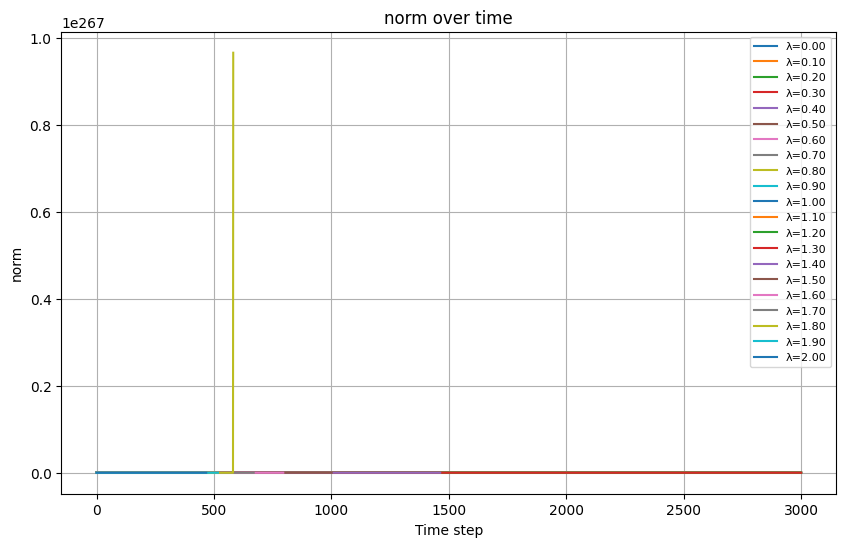

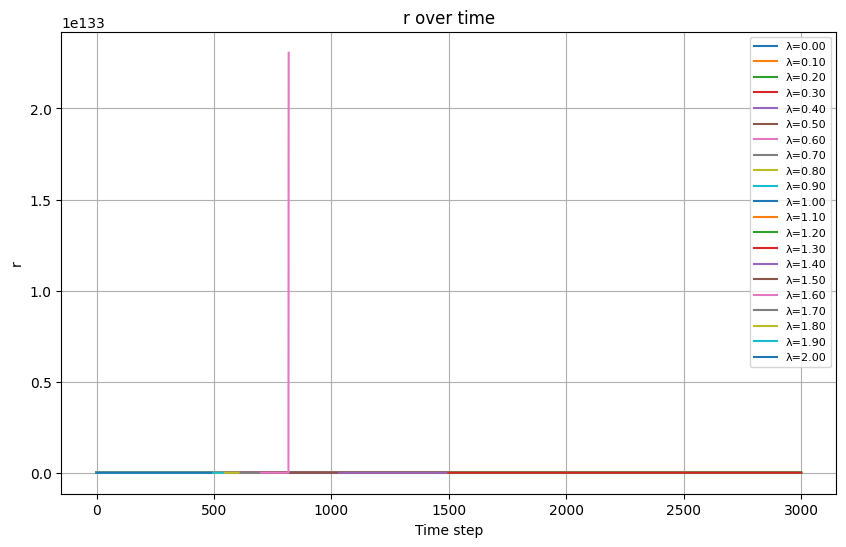

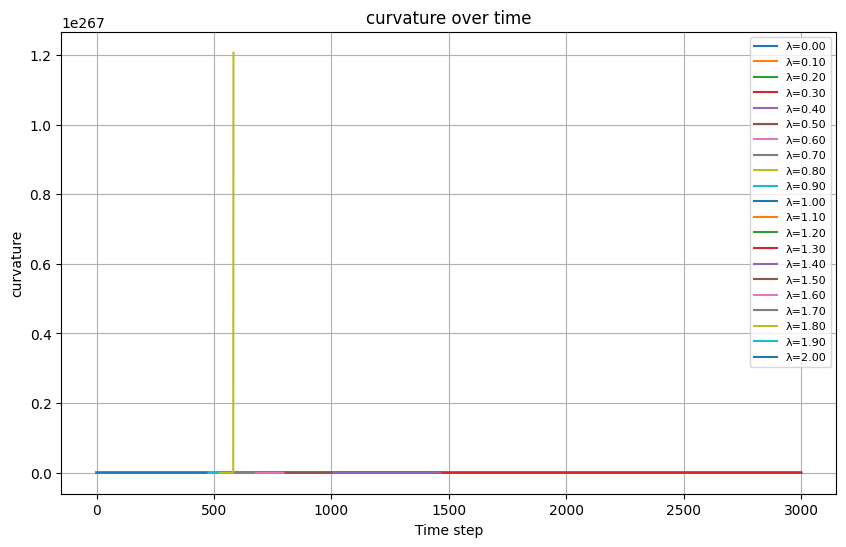

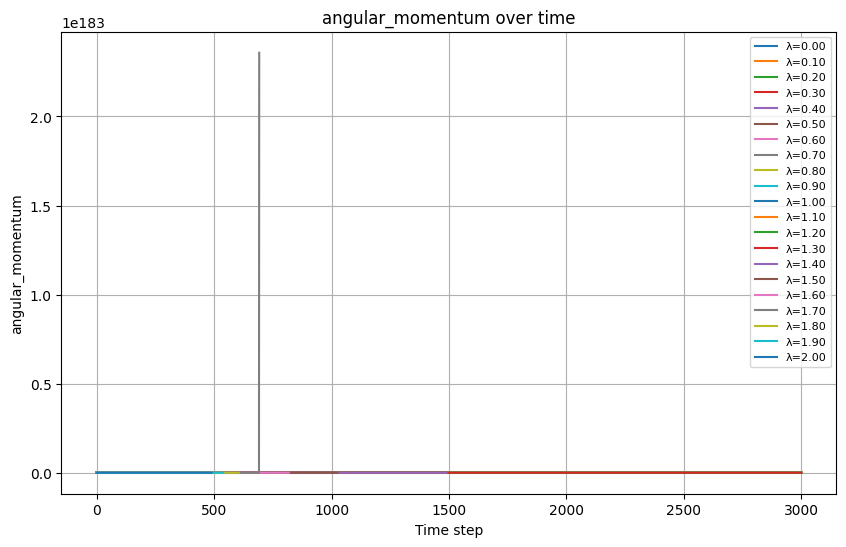

In [ ]:
# HES λ Sweep: Full Simulation in Colab
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Simulation parameters
N_grid = 128
dt = 0.01
T_steps = 3000
x = np.linspace(-1, 1, N_grid)
y = np.linspace(-1, 1, N_grid)
X, Y = np.meshgrid(x, y)

# Field parameters
gamma = 0.01
kappa = 0.1
delta = 0.039
mass = 1.0

# Attractor: Gaussian centered at origin
def attractor(x0, y0, sigma=0.1):
    return np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2))

# Initialize field
def initialize_field():
    return 0.1 * attractor(0, 0)

# Particle injection
r0 = np.array([0.5, 0.0])
v0 = np.array([0.0, 0.2])

# Gradient helper
def gradient(field):
    dx = np.gradient(field, axis=1)
    dy = np.gradient(field, axis=0)
    return dx, dy

# Laplacian helper
def laplacian(field):
    return np.gradient(np.gradient(field, axis=0), axis=0) + np.gradient(np.gradient(field, axis=1), axis=1)

# Run simulation for a given λ
def run_simulation(lambda_val):
    psi = initialize_field()
    r = r0.copy()
    v = v0.copy()

    norm_list = []
    r_list = []
    curvature_list = []
    L_list = []

    for _ in range(T_steps):
        G = attractor(r[0], r[1])
        lap = laplacian(psi)
        psi += dt * (-gamma * lap - kappa * psi + delta * np.abs(psi)**2 * psi + lambda_val * G)

        dx, dy = gradient(psi)
        force = -np.array([dx[N_grid//2, N_grid//2], dy[N_grid//2, N_grid//2]])
        a = force / mass
        v += dt * a
        r += dt * v

        norm_list.append(np.sum(np.abs(psi)**2))
        r_list.append(np.linalg.norm(r))
        curvature_list.append(np.sum(lap**2))
        L_list.append(np.cross(r, v))

    return norm_list, r_list, curvature_list, L_list

# Sweep λ from 0.0 to 2.0
lambda_values = np.linspace(0.0, 2.0, 21)
results = {}

for lam in tqdm(lambda_values):
    norm, r_traj, curv, L = run_simulation(lam)
    results[lam] = {
        'norm': norm,
        'r': r_traj,
        'curvature': curv,
        'angular_momentum': L
    }

# Plot results
def plot_metric(metric_name):
    plt.figure(figsize=(10, 6))
    for lam in lambda_values:
        plt.plot(results[lam][metric_name], label=f"λ={lam:.2f}")
    plt.title(f"{metric_name} over time")
    plt.xlabel("Time step")
    plt.ylabel(metric_name)
    plt.legend(loc='upper right', fontsize=8)
    plt.grid(True)
    plt.show()

plot_metric('norm')
plot_metric('r')
plot_metric('curvature')
plot_metric('angular_momentum')
